In [135]:
import numpy as np
from graphviz import Digraph
import torch
import math

# AutoGrad From Scratch!

__Goal__: build `Value` class which contains differentiable numerical objects. We can create computation graphs with automatic differentiation with these `Value` objects.

On top of holding data, `Value` should hold:
- Children (computation graph)
- Gradients
- Backprop function
- Bells and whistles for graphing

In [36]:
## Plots a computation graph from root
def draw_dot(root, format='png', rankdir='LR'):
    """
    root: final Value node
    format: 'png', 'svg', etc.
    rankdir: 'LR' for left-to-right, 'TB' for top-to-bottom
    """
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # Node showing label, data, grad
        dot.node(
            name=uid,
            label=f'{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}',
            shape='record'
        )

        # Operation node, if this value came from an op
        if n._op:
            op_id = uid + n._op
            dot.node(name=op_id, label=n._op)
            dot.edge(op_id, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

## PyTorch API

In [187]:
x1 = torch.tensor(1., requires_grad=True)
x2 = torch.tensor(2., requires_grad=True)
x3 = torch.tensor(5., requires_grad=True)
x4 = torch.tensor(4., requires_grad=True)

x1x2 = x1 * x2
x3x4 = x3 * x4

a = x1x2 ** 2
b = torch.exp(x3x4)
b.retain_grad()

L = a + b

L.backward()
L.retain_grad()

print(x1.grad)
print(x2.grad)
print(x3.grad)
print(x4.grad)
print(b.grad)

tensor(8.)
tensor(4.)
tensor(1.9407e+09)
tensor(2.4258e+09)
tensor(1.)


In [186]:
L

tensor(4.8517e+08, grad_fn=<AddBackward0>)

## `Value` Class

We want objects of this class to contain `data` as a float, optional `name`s, `gradient`s stored, and `children` to keep track of relations. We should be able to do standard operations on members of this class. Start with addition, multiplication, exponentiation, logs first. We can always add more! PLus:
- backward() fucntion
- Keep track of gradients

### Understanding A Key Point: `grad` and `_backprop`

- `grad` is a field which tells the gradient of the root w.r.t. `self`: this is accumulated
    - `grad` +=  the local gradient times the outgoing gradient
    - `grad` = dL / d`self` = dL / d`parent` * d`parent` / d`self`
- `_backprop` is a function that applies the local chain rule to propagate gradients to parents

In [294]:
class Value:
    def __init__(self, data:float, _children=(), label='', _op=''):
        self.data = data
        self._prev = set(_children)
        self.label = label
        self._op = _op
        
        ## backprop and grad as well
        self.grad = 0
        self._backprop = lambda: None
        
    def __repr__(self):
        return f'{self.label}:{self.data}'
    
    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
            
        """
        
        L = a + b
        
        want to find out how to backprop through result
        change gradients of a and b: use gradient at result to change the gradients of a and b
        
        dL/da = 1
        dL/db = 1
            
        """
        result = Value(self.data + other.data, (self, other), _op = '+')
        
        def backprop():
            # d result / d self = d/d(self) (self + other) = 1
            # d L / d result = result.grad
            self.grad += 1 * result.grad
            
            # d result / d other = d/d(other) (self + other) = 1
            # d L / d result = result.grad
            other.grad += 1 * result.grad
        
        result._backprop = backprop
        return result
    
    def __radd__(self, other):
        return self + other
    
    def __neg__(self):
        result = Value(-1 * self.data, (self,), label=f'-{self.label}', _op = '-')
        
        def backprop():
            self.grad += -1 * result.grad
            
        result._backprop = backprop
        return result
    
    def __sub__(self, other):
        result = self + (-other)
        result._op = '-'
        return result
    
    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
            
        """
        L = ab
        dL / da = b
        dL / db = a
        
        also have to pass the gradient at L through
        """
        result = Value(self.data * other.data, (self, other), _op = '*')
        
        def backprop():
            self.grad += other.data * result.grad
            other.grad += self.data * result.grad
        
        result._backprop = backprop
        
        return result
    
    def __truediv__(self, other):
        # a / b equiv a * (1 / b) = a * (b)^-1
        if not isinstance(other, Value):
            other = Value(other)
            
        result = self * (other**(-1))
        result._op = '/'
        return result
    
    def __pow__(self, power:float):
        # d/dx x^a = a x ^(a-1)
        result = Value(self.data ** power, (self,), _op = f'^{power}')
        
        def backprop():
            self.grad += (power) * self.data ** (power - 1) * result.grad
            
        result._backprop = backprop
        return result
    
    def exp(self):
        result = Value(math.exp(self.data), (self,), _op = f'exp')
        
        def backprop():
            # d/dx e^u(x) = e^u(x) * d/dx u(x)
            self.grad += result.data * result.grad
            
        result._backprop = backprop
        return result
    
    # tanh, ReLU soon to come! 
        

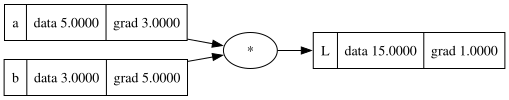

In [235]:
a = Value(5, label='a')
b = Value(3, label='b')
L = a * b; L.label = 'L'

L.grad = 1
L._backprop()

draw_dot(L)

In [252]:
a = Value(5, label='a')
b = Value(3, label='b')
L = a + b; L.label = 'L'

L.grad = 1
L._backprop()

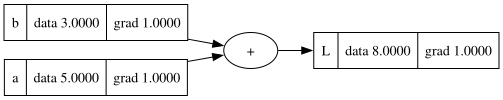

In [244]:
draw_dot(L)

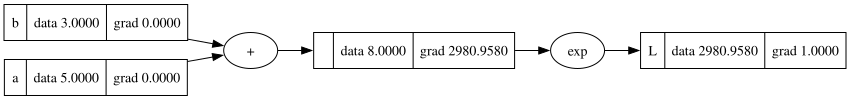

In [253]:
a = Value(5, label='a')
b = Value(3, label='b')
c = a + b; L.label = 'c'

L = c.exp(); L.label = 'L'

L.grad = 1
L._backprop()

draw_dot(L)

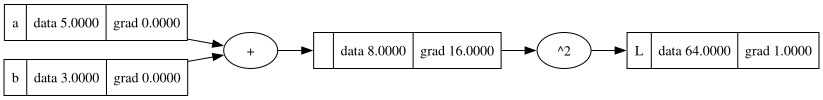

In [256]:
a = Value(5, label='a')
b = Value(3, label='b')
c = a + b; L.label = 'c'

# c = 8
# L = c^2
# d / dc c^2 = 2c = 16

L = c**2; L.label = 'L'

L.grad = 1
L._backprop()

draw_dot(L)

In [265]:
x1 = Value(1, label='x1')
x2 = Value(2, label='x2')

x3 = Value(5, label='x3')
x4 = Value(4, label='x4')

x1x2 = x1 * x2; x1x2.label = 'x1x2'
x3x4 = x3 * x4; x3x4.label = 'x3x4'

a = x1x2 ** 2; a.label = 'a'
b = x3x4.exp(); b.label = 'b'

L = a + b; L.label = 'L'

L.grad = 1
L._backprop()
a._backprop()
b._backprop()
x1x2._backprop()
x3x4._backprop()

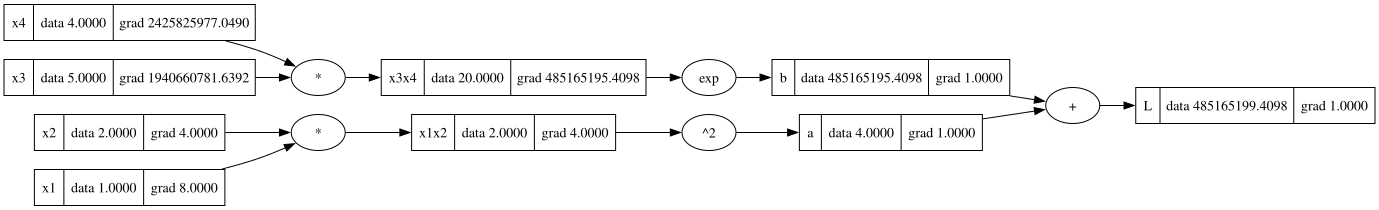

In [266]:
draw_dot(L)

In [ ]:
## PyTorch Values

# tensor(8.) : x1
# tensor(4.) : x2
# tensor(1.9407e+09) : x3
# tensor(2.4258e+09) : x4
# tensor(1.) : L

In [179]:
a = Value(5, label='a')
b = Value(3, label='b')
c = b.__neg__(); c.label = 'c'
d = a / c; d.label = 'd'

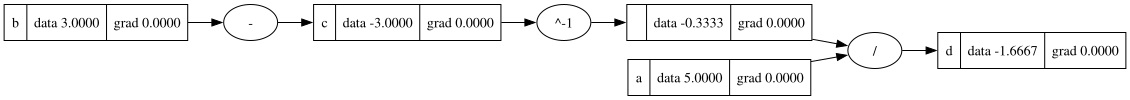

In [180]:
draw_dot(d)

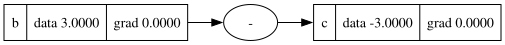

In [172]:
draw_dot(c)

## The `Value` class works! We can propagate gradients backwards correctly!

But, we have to manually call `_backward()`. 

Final step: make a `backward()` function which will propagate through the entire network.

In [295]:
def topo_sort(root):
    visited = set([])
    ordering = []
    
    def dfs(node):
        if node not in visited:
            visited.add(node)
            
            for child in node._prev:
                dfs(child)
                
            ordering.append(node)
    dfs(root)
    return ordering

def backward(root):
    ordering = topo_sort(root)
    
    for cur in ordering:
        cur.grad = 0
        
    root.grad = 1
    
    for cur in reversed(ordering):
        if cur._prev is not None:
            cur._backprop()

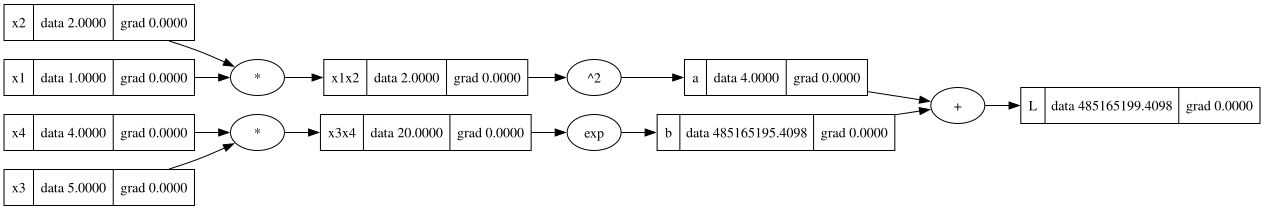

In [296]:
x1 = Value(1, label='x1')
x2 = Value(2, label='x2')

x3 = Value(5, label='x3')
x4 = Value(4, label='x4')

x1x2 = x1 * x2; x1x2.label = 'x1x2'
x3x4 = x3 * x4; x3x4.label = 'x3x4'

a = x1x2 ** 2; a.label = 'a'
b = x3x4.exp(); b.label = 'b'

L = a + b; L.label = 'L'
draw_dot(L)

In [297]:
backward(L)

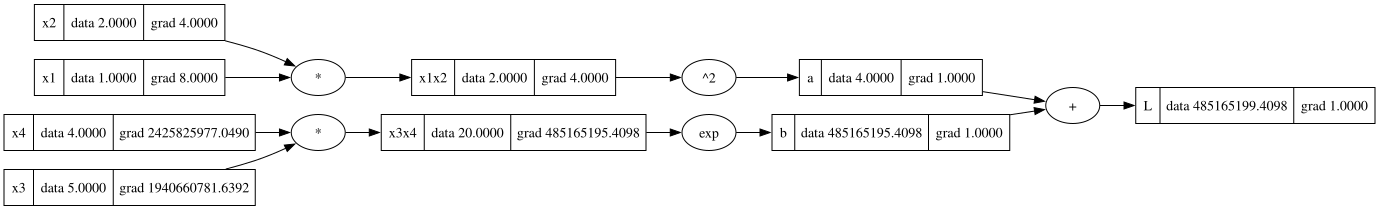

In [298]:
draw_dot(L)

In [299]:
backward(L)

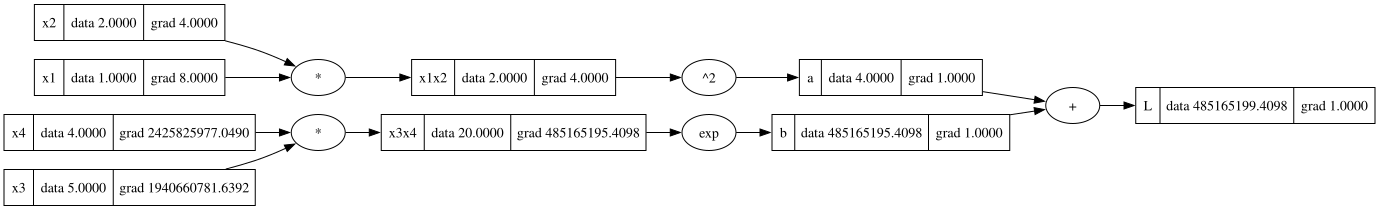

In [300]:
draw_dot(L)